## 0) Imports and stuff

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
cd "drive/MyDrive/tests-sara"

/content/drive/MyDrive/tests-sara


In [3]:
"""
%load_ext autoreload
%autoreload 2
"""

'\n%load_ext autoreload\n%autoreload 2\n'

In [4]:
from data_processing.dataloader import get_BAA_DFS
from data_processing.dataset import BAA_Dataset
from data_processing.preprocessing import get_transforms
from model.model import simple_BAA_model
from model.train import train_model
from model.eval import evaluate
from model.gradcam import GradCAM

from torch.utils.data import DataLoader
import torch
import matplotlib.pyplot as plt
import numpy as np
from os import path, listdir, getcwd
from pathlib import Path

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device: {}'.format(device))

Device: cuda


## 1) Data preparation

In [6]:
batch_size = 64
num_workers = 6

target_image_size = (150, 100)

### 1.1) Loading data

In [7]:
## wherever you stored data: this folder needs to have the .csv and either an "images" folder, either "segmented_images".
## if you don't have have one just put none -> will download with kagglehub library
datapath = path.join(getcwd(), "")

In [8]:
# you will need to include kagglehub in dependencies if folders don't exist
train_df, val_df = get_BAA_DFS(datapath = datapath, imgs_segmented = False)

100%|██████████| 9.29G/9.29G [09:16<00:00, 17.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kmader/rsna-bone-age/versions/2

Full df size len: 12611
train/val sizes: 10088/2523


/content/drive/MyDrive/tests-sara/data_processing/dataloader.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["male"].replace([True, False], [1.0, 0.0], inplace=True)
/content/drive/MyDrive/tests-sara/data_processing/dataloader.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["male"].r

### 1.2) Transforms

In [9]:
transforms = get_transforms(target_image_size)

### 1.3) Dataset

In [10]:
train_dataset = BAA_Dataset(train_df, transforms)
val_dataset = BAA_Dataset(val_df, transforms)

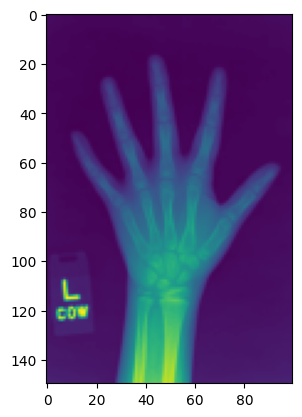

In [12]:
img, _, _ = val_dataset.__getitem__(0)
img = img.squeeze(0).cpu()
plt.imshow(img)

### 1.4) DataLoader

In [13]:
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## 2) Model

### 2.1) Initial Resnet18

In [14]:
model = simple_BAA_model().to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]


### 2.2) Loading a Checkpoint

In [15]:
checkpoint_path = path.join(getcwd(), "model", "checkpoints")
specific_checkpoint = "checkpoint-current-best.pth"

In [16]:
checkpoint = torch.load(path.join(checkpoint_path, specific_checkpoint), weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

## 3) Training

In [17]:
learning_rate = 0.01
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)
criterion = torch.nn.L1Loss()
n_epochs = 5


### 3.1) Training loop

In [18]:
train_losses = []
val_losses = []

In [19]:
# train_losses, val_losses = train_model(model, train_dataloader, val_dataloader, n_epochs, device, optimizer, criterion, checkpoint_path)

### 3.2) Eval only

In [22]:
mae = evaluate(model, val_dataloader, device, criterion)

  0%|          | 0/40 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
100%|██████████| 40/40 [01:26<00:00,  2.17s/it]


In [23]:
print(mae)

17.32401791367321


### 3.3) Visualizing results

In [24]:
# train_losses[-1], val_losses[-1]

In [ ]:
plt.figure()
plt.plot(np.arange(len(train_losses)), train_losses)
plt.plot(np.arange(len(val_losses)), val_losses)
plt.legend(['train_loss', 'val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss value (boneage months)')
plt.title('{}: Train/val loss'.format("current model training results"));

### 3.4) Saving current model

In [26]:
specific_checkpoint = "checkpoint-current-best.pth"

In [27]:
"""
torch.save({
    'model_state_dict': model.state_dict()
}, path.join(checkpoint_path, specific_checkpoint))
"""

"\ntorch.save({\n    'model_state_dict': model.state_dict()\n}, path.join(checkpoint_path, specific_checkpoint))\n"

## 4) GRAD-Cam

### 4.1) Set the target layer
You need to define the target layer: usually the last convolutional layer from whichever backbone model you chose.
For Restnet 18, it's divided into 4 "blocks" of layers, we want the last layer of the last block:

In [28]:
target_layer = model.cnn.layer4[-1]

### 4.2) Generate Grad-CAM

In [29]:
grad_cam = GradCAM(model, target_layer)

### 4.2) Apply it to a single input

In [30]:
img, gender, age, idx = val_dataset.get_random_items(1)[0]

In [31]:
u_img = img.unsqueeze(0).to(device)
u_gender = gender.unsqueeze(0).to(device)

print(f"img shape: {u_img.shape}, gender shape: {u_gender.shape}")

img shape: torch.Size([1, 1, 150, 100]), gender shape: torch.Size([1])


In [36]:
cam = grad_cam.generate(u_img, u_gender)
cam = cam.cpu()
resized_cam = grad_cam.resize_cam(cam, target_image_size)

In [37]:
pred = model(u_img, u_gender)

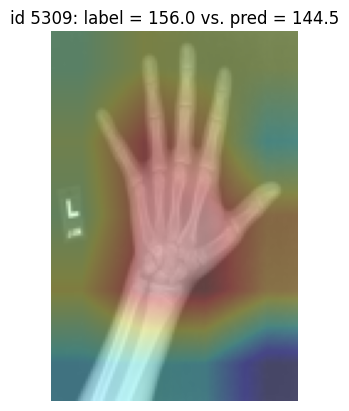

In [49]:
img = img.squeeze(0).cpu()
plt.imshow(resized_cam, cmap='jet_r', alpha=0.5)
plt.imshow(img, cmap='gray', alpha=0.5)
plt.axis('off')
plt.title(f"id {idx}: label = {age:.4} vs. pred = {pred.item():.4}")
plt.show()

### 4.3) Apply it to multiple inputs

In [39]:
rand_inputs = val_dataset.get_random_items(9)

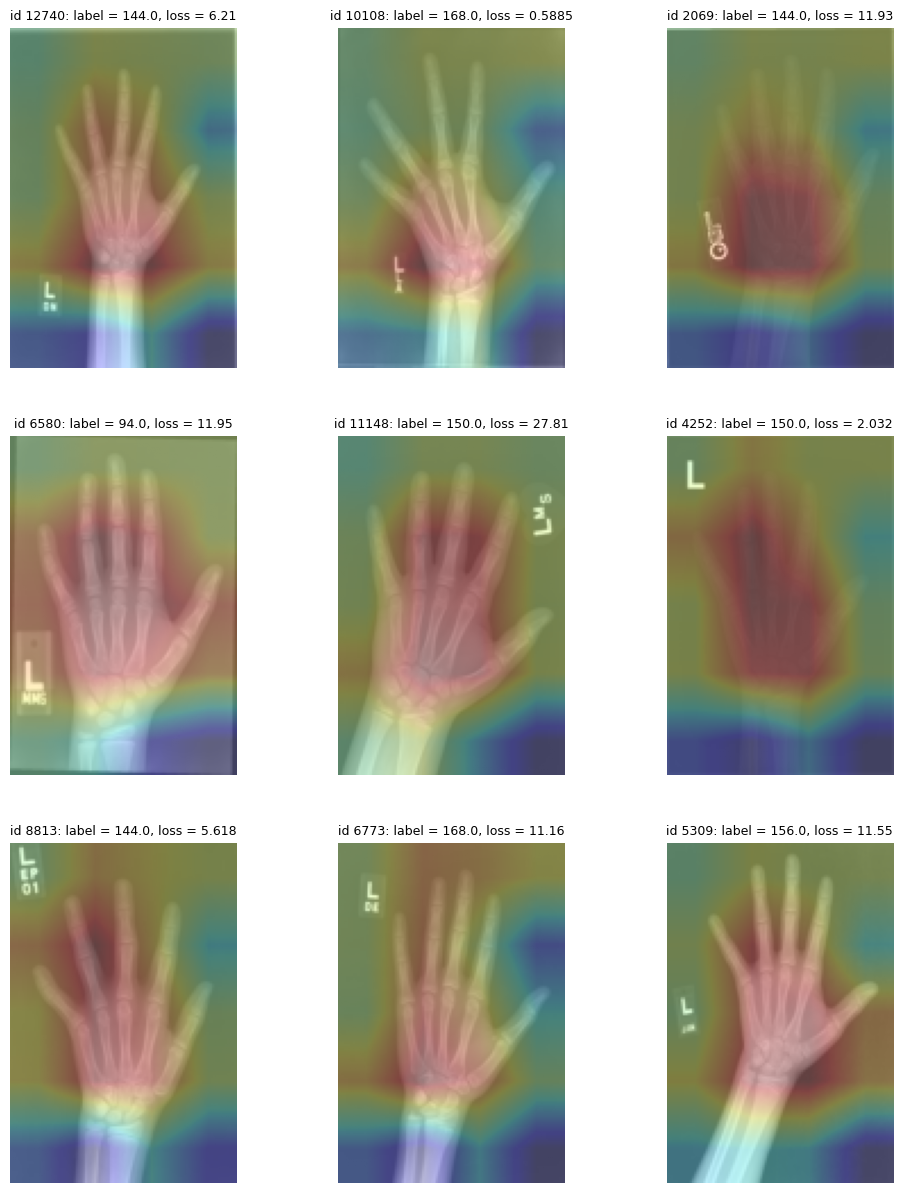

In [47]:
fig, ax = plt.subplots(nrows=3, ncols=3, sharex=True, sharey=False)
fig.set_figheight(15)
fig.set_figwidth(12)

for test_input, sub_plot in zip(rand_inputs, fig.axes):

    img, gender, age, idx = test_input
    u_img = img.unsqueeze(0).to(device)
    u_gender = gender.unsqueeze(0).to(device)

    cam = grad_cam.generate(u_img, u_gender)
    cam = cam.cpu()
    resized_cam = grad_cam.resize_cam(cam, target_image_size)

    pred = model(u_img, u_gender)

    img = img.squeeze(0).cpu()
    sub_plot.axis('off')
    sub_plot.imshow(resized_cam, cmap='jet_r', alpha=0.5)
    sub_plot.imshow(img, cmap='gray', alpha=0.5)
    sub_plot.set_title(f"id {idx}: label = {age:.4}, loss = {criterion(age, pred.squeeze(0)):.4}", fontsize = 9)

In [ ]:
2